# Section 01: PyTorch Workflow

this is the first Notebook from PyTorch-ZTM course by D. Bourke

https://academy.zerotomastery.io/courses/learn-pytorch/lectures/41098485

## Import packages

In [4]:
import torch 

In [6]:
import torch.nn as nn
import matplotlib.pyplot as plt

## Setting the device

In [7]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

We are going to use the unified memory available on Apple Silicon so the device is et to `mps` 
>(Metal Performance Shaders)

## 1. Data (preparing and loading)

In this section we will learn about linear regression

$ y = ax + b$ ;a = intercept and b = the slope (gradient)

In [ ]:
weight = 0.7 # the intercept (in the linear regression)
bias = 0.3 # the slope (in the linear regression)

# Create a range of numbers
start = 0
end = 1 
step = 0.02
# add an additional dimensions to the tensor created
X = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)

In [15]:
X2 = torch.arange(start=start, end=end, step=step)
X2.shape, X2.ndim, X.shape, X.ndim

(torch.Size([50]), 1, torch.Size([50, 1]), 2)

In [23]:
y = weight*X + bias

In [24]:
# splitting into train and test set
train_split = int(0.8*len(X))
X_train, X_test, y_train, y_test = X[:train_split], X[train_split:], y[:train_split], y[train_split:]
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [118]:
def plot_data(x_train = X_train, 
              y_train = y_train, 
              y_test = y_test, 
              x_test = X_test, 
              predictions = None):
    plt.figure(figsize=(12,8))
    _, ax = plt.subplots()
    ax.scatter(x_train, y_train)
    ax.scatter(x_test, y_test, color="g")
    if predictions is not None:
        ax.scatter(x_test, predictions, color="r")
        ax.legend(["Train", "Test", "Prediction"])
    else:
        ax.legend(["Train", "Test"])
    plt.show()

<Figure size 1200x800 with 0 Axes>

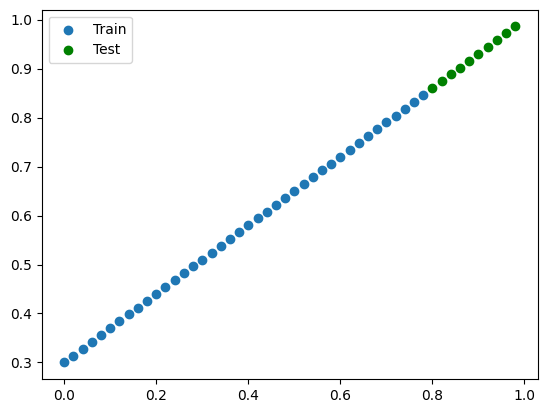

In [31]:
plot_data()

In [35]:
# First model
# inherit from nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # we need to specify if we are using parameters
        # requires grad means that we want to compute the gradient via backpropagation
        self.weight = nn.Parameter(torch.randn(1, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float))
    def forward(self, inputs):
        return inputs*self.weight + self.bias

There is something worth mentionning here:

> In PyTorch if we use `nn.Parameter` we do not need to specify that we want the gradient to be computed as this is automatically dealt with because we use the `nn.Parameter` to make PyTorch know that we identify this quantity as a parameter. If we do not use it, the we need to specify it like in the second example. It works as well but requires to specify the `require_grad = True`. This is true only when we do numpy-like operations but in the case of neural networks from own model, we need to specify the fact that our tensors are parameters so we need to use `nn.Parameter`


> Unlike  **TensorFlow**, the gradients are not automatically evaluated but are asked to be if needed. This allows for more control, flexibility, better memory management.

We need to initialize the parameters at random and the thing is that when used in conjuction of activation function we may have different performances

### PyTorch model building essentials

1. `torch.nn` - contains all of the building block for computational graphs
2. `torch.nn.Parameter` - What our model parameters need to be learned
3. `torch.nn.Module`- Base classe for all neural network module. If we subclass it we need to set the `forward`ourselves because it explains what happens in the forward pass.
4. `torch.optim`- this where the optimizer lives

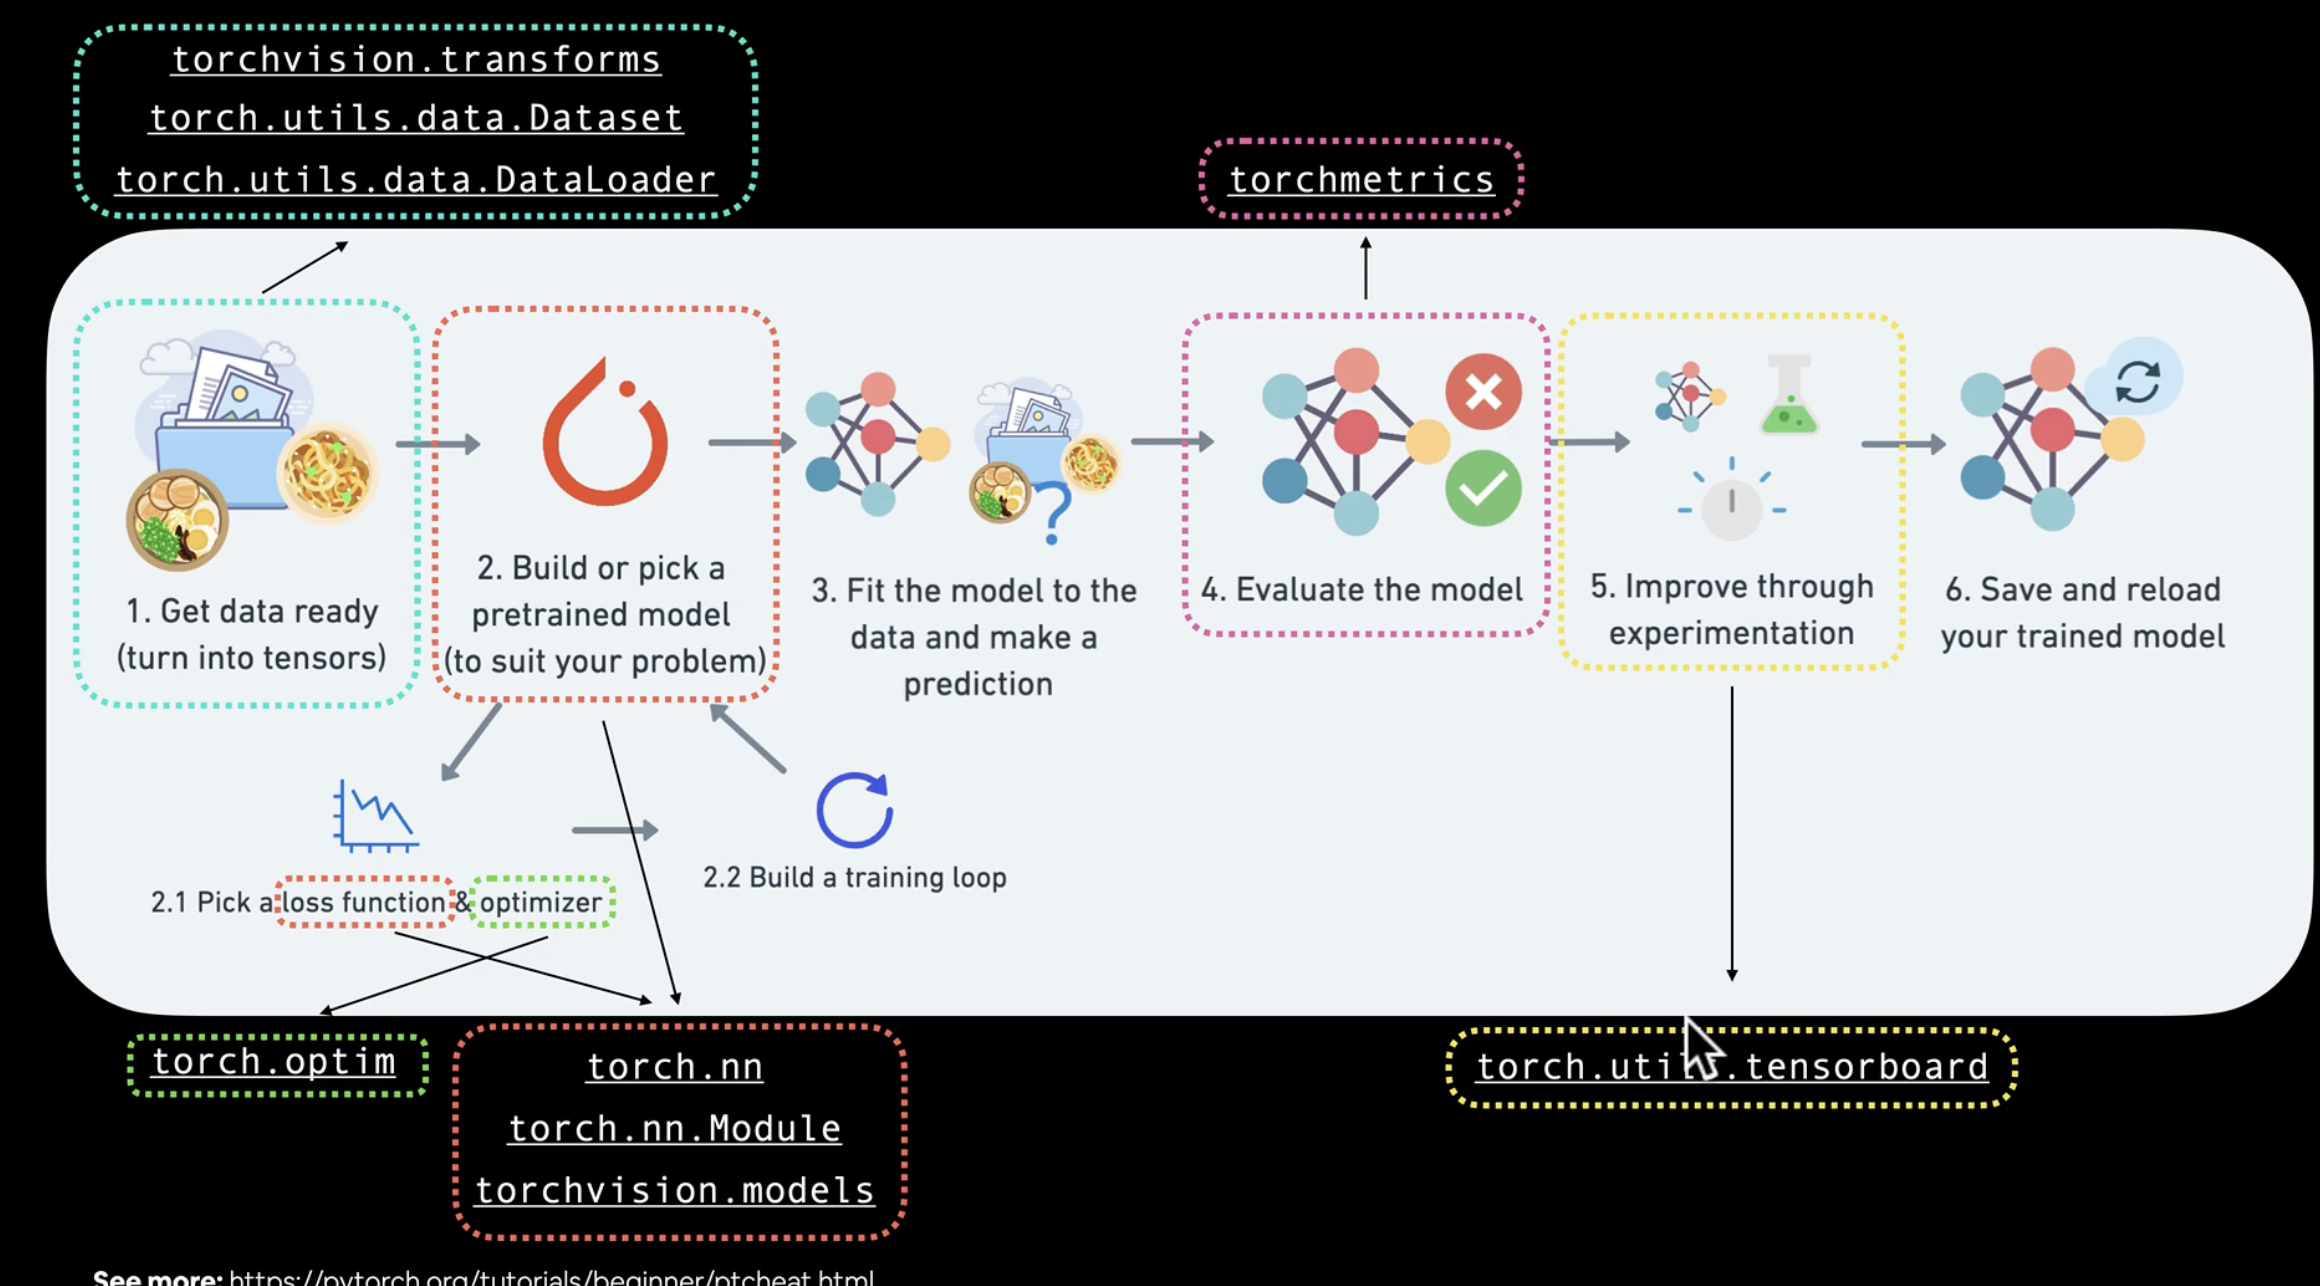

In [133]:
model_0 = LinearRegressionModel()

In [134]:
torch.manual_seed(42) # tf.keras.set_seeed(42)

In [135]:
for item in model_0.parameters():
    print(item)

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


In [136]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [137]:
from torchinfo import summary

In [138]:
summary(model_0)

Layer (type:depth-idx)                   Param #
LinearRegressionModel                    2
Total params: 2
Trainable params: 2
Non-trainable params: 0

In [174]:
from torch.optim import Adam
optimizer = Adam(lr=0.001, params=model_0.parameters())

In [140]:
criterion = nn.MSELoss()

In [141]:
# making prediction using torch.inference_mode()
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

> Note: in order to turn off the gradient tracking that we see here we can perform the `torch.inference_mode()` in order to avoir keeping track of that data hence the inference will be faster. Also this helps with the device on which the calculation is made and can be beneficial if we forget to transfer bacck to the CPU for plotting for instance,.

> the old way: `with torch.no_grad()`

Philosophie de conception :
1. `inference_mode()` est conçu spécifiquement pour l'inférence
Optimisé pour la performance
Comportement "smart" pour l'utilisateur
Moins de vérifications, plus de vitesse
2. `no_grad()` est plus général
Désactive juste les gradients
Garde le comportement normal du tenseur
Plus flexible mais moins optimisé
3. Mode normal garde toutes les informations
Utile pour le débogage
Permet de faire des calculs supplémentaires avec le tenseur

In [142]:
with torch.inference_mode():
    y_preds2 =  model_0(X_test)

In [143]:
y_preds2

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [144]:
criterion(y_preds2, y_test)

tensor(0.2450)

use the `.detach().numpy()` to convert back to numpy arrays instead of `to("cpu").numpy()` (not sure why)

In [210]:
model_0 = LinearRegressionModel()

In [211]:
optimizer = Adam(lr=0.001, params=model_0.parameters())

In [212]:
torch.manual_seed(42)

In [213]:
epochs = 500
# track different values
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_0.train() # train mode (the parameters for which we need the gradients are computed)
    predictions = model_0(X_train) # make a prediction using the forward method from our model: This calls automatically the forward method;
    loss = criterion(predictions, y_train) # evaluate the loss
    optimizer.zero_grad() # set the gradient to zero to avoid gradient accumulation. 

    loss.backward() # evalute the backpropagation
    optimizer.step() # increment the optimizer and applies the computation (gradient descent)
    if epoch % 20 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        print(f"Epoch: {epoch} - Loss: {loss}")

Epoch: 0 - Loss: 0.10493002086877823
Epoch: 20 - Loss: 0.08764377981424332
Epoch: 40 - Loss: 0.07235021889209747
Epoch: 60 - Loss: 0.05913267284631729
Epoch: 80 - Loss: 0.04787302389740944
Epoch: 100 - Loss: 0.03839036822319031
Epoch: 120 - Loss: 0.030492985621094704
Epoch: 140 - Loss: 0.02399190329015255
Epoch: 160 - Loss: 0.018705107271671295
Epoch: 180 - Loss: 0.014460183680057526
Epoch: 200 - Loss: 0.011096494272351265
Epoch: 220 - Loss: 0.008467093110084534
Epoch: 240 - Loss: 0.0064398907124996185
Epoch: 260 - Loss: 0.004898634739220142
Epoch: 280 - Loss: 0.003742960747331381
Epoch: 300 - Loss: 0.0028880219906568527
Epoch: 320 - Loss: 0.002263596747070551
Epoch: 340 - Loss: 0.0018127787625417113
Epoch: 360 - Loss: 0.00149042927660048
Epoch: 380 - Loss: 0.001261489000171423
Epoch: 400 - Loss: 0.0010992891620844603
Epoch: 420 - Loss: 0.0009839464910328388
Epoch: 440 - Loss: 0.000900949991773814
Epoch: 460 - Loss: 0.0008399038342759013
Epoch: 480 - Loss: 0.0007935223402455449


Note the link between the loss and the optimizer, therefore the parameters, is made via the graph underneath the hood

The idea behind the `eval` mode is to turn-off some of useless things when evaluating (like `dropout` or `batchnorm`) because we are testing only the patterns learn during training.

In [214]:
with torch.no_grad(): # deactivate the tracking of the gradients
    model_0.eval()
    preds = model_0(X_test)

In [215]:
preds

tensor([[0.8104],
        [0.8220],
        [0.8336],
        [0.8452],
        [0.8568],
        [0.8684],
        [0.8801],
        [0.8917],
        [0.9033],
        [0.9149]])

<Figure size 1200x800 with 0 Axes>

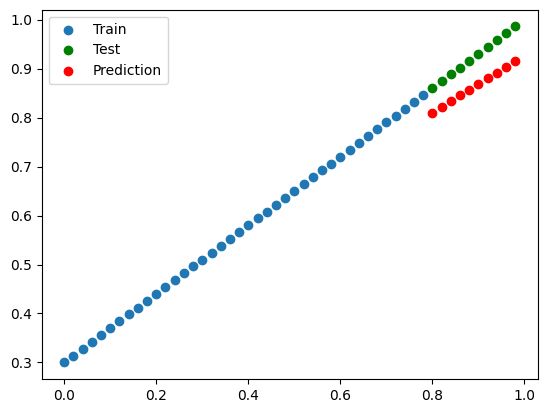

In [216]:
plot_data(predictions=preds);

In [217]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.5809], requires_grad=True),
 Parameter containing:
 tensor([0.3456], requires_grad=True)]

In [218]:
losses = [item.detach().numpy() for item in loss_values]

<Figure size 1200x800 with 0 Axes>

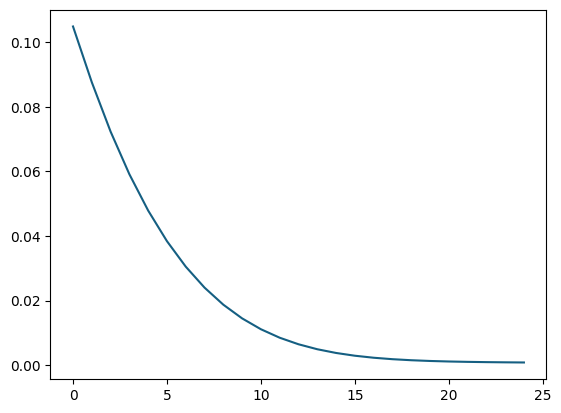

In [219]:
plt.figure(figsize=(12,8))
_, ax = plt.subplots()
ax.plot(losses, color = "#155F82")
plt.show()

Ok so far we have trained the model as well as evaluated it.

Now how can we run it, i.e., save it and reload it

to save a model in PyTorch there are three main ways to save and load

1. `torch.save()`- save a PyTorch object in a `pickle` format (binary protocols)
2. `torch.load()`- load a saved PyTorch object
3. `toch.nn.Module.load_state_dict()` - load a model saved state dictionnary

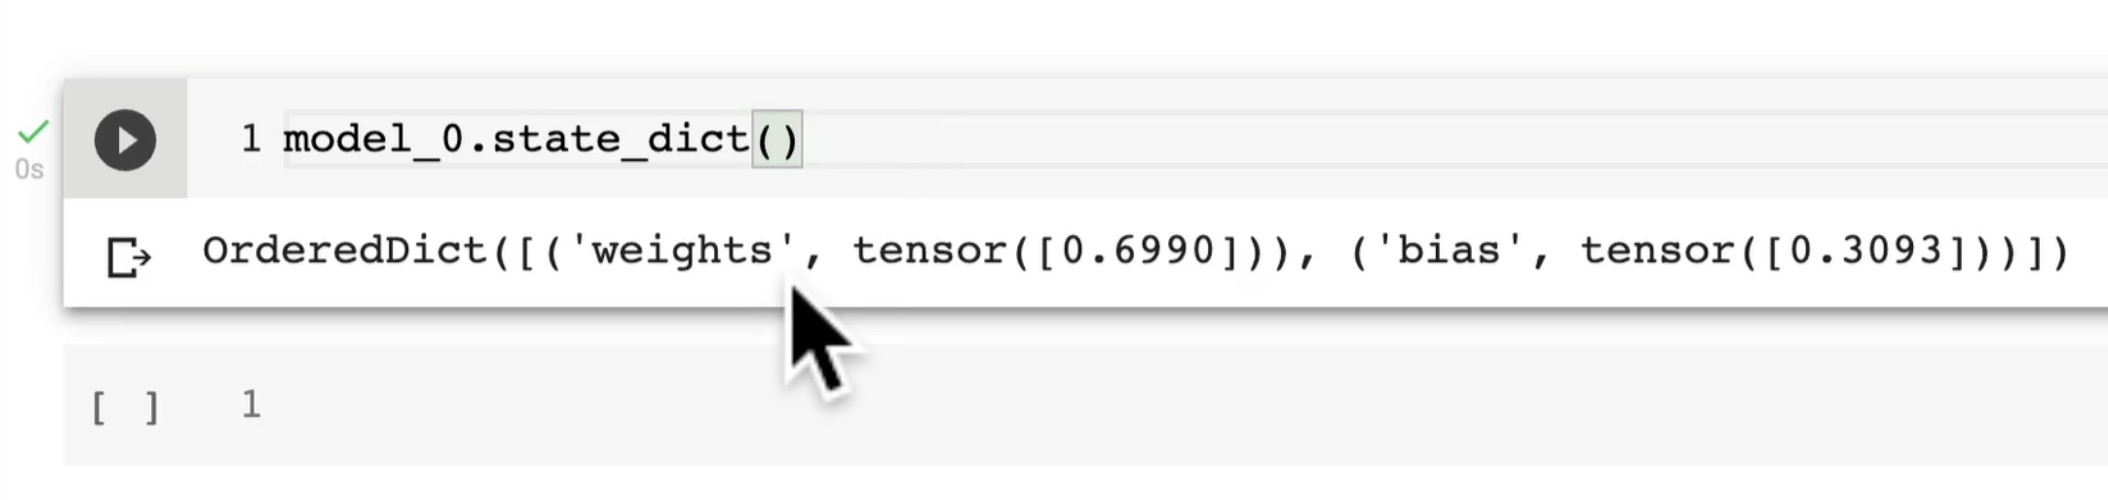

In [223]:
# saving a model in PyTorch
from pathlib import Path
import os

#1. Create a model directory
MODEL_PATH = Path(os.getcwd()) / "models"
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [226]:
# 2. Create a model save path

MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

In [228]:
#3. Save the mode (state_dict (RECOMMENDED))
torch.save(model_0.state_dict(), f=MODEL_SAVE_PATH)

Because we only saved the weight and biases into a `save_dict`what we need to do is to instanciate a new model, load the dict containing the saved information and feed this new instance with it.

In [234]:
loaded_model_0 = LinearRegressionModel()

In [244]:
# load the model
# because our instance is a nn.Module (subclass) we can use the `.load_state_dict()` method on it 
weight_biases_model_0 = torch.load(f=MODEL_SAVE_PATH)  # load the weights and biases
loaded_model_0.load_state_dict(weight_biases_model_0) # this how we apply/set the weights and biases to the model

<All keys matched successfully>

In [238]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.5809])), ('bias', tensor([0.3456]))])

In [243]:
loaded_model_0.eval() # set the evaluate mode
with torch.inference_mode(): # stop the tracking of the gradients
    loaded_model_0_preds = loaded_model_0(X_test)

In [242]:
preds

tensor([[0.8104],
        [0.8220],
        [0.8336],
        [0.8452],
        [0.8568],
        [0.8684],
        [0.8801],
        [0.8917],
        [0.9033],
        [0.9149]])

In [241]:
loaded_model_0_preds

tensor([[0.8104],
        [0.8220],
        [0.8336],
        [0.8452],
        [0.8568],
        [0.8684],
        [0.8801],
        [0.8917],
        [0.9033],
        [0.9149]])

## Putting it all together

### Setting the problem up

In [245]:
import torch
import torch.nn as nn

print(torch.__version__)

2.12.0


A good habit is to write a device agnostic code, i.e., use what is available either `cpu`or `gpu`(on MacOS with M-series chip we use `mps`(Metal Performance Shaders))

In [246]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

mps


### 1. Get some data

In [546]:
weight = 5.0
bias = 3.0 
X = torch.arange(start=0, end=25, step=0.5)
eps = torch.rand(X.shape[0])*20-1
y = weight*X + bias+eps

<Figure size 1200x800 with 0 Axes>

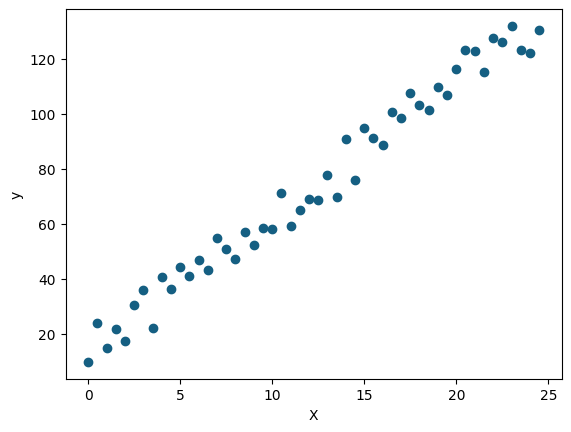

In [547]:
# plot the data
plt.figure(figsize=(12,8))
_, ax = plt.subplots()
ax.scatter(X,y,color="#155F82")
ax.set_xlabel("X")
ax.set_ylabel("y")
plt.show();

### 2. Build the model

In [488]:
torch.manual_seed(42)

In [372]:
class LinearRegression(nn.Module): # must inherit the nn.Module to be considered a Model with parameters
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))


    def forward(self, inputs:torch.Tensor) -> torch.Tensor:
        return self.weight*inputs + self.bias

In [490]:
class LinearRegression2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
    
    def forward(self, inputs:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(inputs)

In [491]:
model_1 = LinearRegression2()

In [492]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

### 3. Splitt the data

In [493]:
train_split_ratio = int(0.8*len(X))

In [548]:
X_train, X_test, y_train, y_test = X[:train_split_ratio], X[train_split_ratio:], y[:train_split_ratio], y[train_split_ratio:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([40]), torch.Size([10]), torch.Size([40]), torch.Size([10]))

<Figure size 1200x800 with 0 Axes>

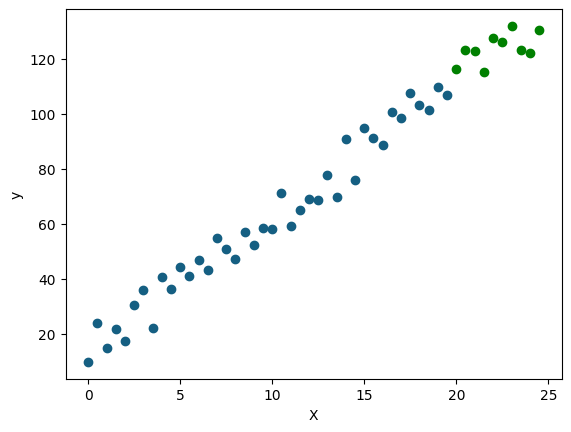

In [549]:
# plot the data
plt.figure(figsize=(12,8))
_, ax = plt.subplots()
ax.scatter(X_train,y_train,color="#155F82")
ax.scatter(X_test,y_test,color="green")
ax.set_xlabel("X")
ax.set_ylabel("y")
plt.show();

### 4. Train the model

In [550]:
epochs = 200
optimizer = torch.optim.Adam(lr=0.1, params=model_1.parameters())
criterion = nn.L1Loss()

In [551]:
loss_values = []
eval_loss_values = []

In [552]:
model_1.to(device)

LinearRegression2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [562]:
# A Linear layer expects a 1-dimesion so we need to unsqueeze the data
# in order to know that we first need to determine the shape of the data and look at the documentation to determine
# the expected shape for the layer we are using.
X_train = X_train.unsqueeze(1)  # (N,) → (N, 1)
X_test = X_test.unsqueeze(1)

In [554]:
for epoch in range(epochs):
    #------- Training loop ------ 
    # mode in train mode
    model_1.train()
    # data to device:
    X_train, y_train = X_train.to(device), y_train.to(device)
    # Make a prediction:
    preds = model_1(X_train)
    # evaluate the loss:
    loss = criterion(preds.squeeze(), y_train)
    # zero the gradient
    optimizer.zero_grad()
    # Backprop
    loss.backward()
    # step the optimizer (apply changes)
    optimizer.step()

    #------- Eval loop ------ 
    model_1.eval()
    X_test, y_test = X_test.to(device), y_test.to(device)
    with torch.inference_mode():
        eval_ = model_1(X_test)
    eval_loss = criterion(eval_.squeeze(), y_test)

    if epoch % 10 == 0:
        print(f"Epochs: {epoch} | Loss: {loss} | Eval loss: {eval_loss}")
    
    loss_values.append(loss)
    eval_loss_values.append(eval_loss)

Epochs: 0 | Loss: 9.790014266967773 | Eval loss: 8.27518367767334
Epochs: 10 | Loss: 6.436868190765381 | Eval loss: 9.50915241241455
Epochs: 20 | Loss: 6.11435079574585 | Eval loss: 6.745587348937988
Epochs: 30 | Loss: 5.903833866119385 | Eval loss: 5.619842529296875
Epochs: 40 | Loss: 5.652604103088379 | Eval loss: 5.867910861968994
Epochs: 50 | Loss: 5.446702003479004 | Eval loss: 5.62012243270874
Epochs: 60 | Loss: 5.2859787940979 | Eval loss: 5.5948920249938965
Epochs: 70 | Loss: 5.156749248504639 | Eval loss: 5.55578088760376
Epochs: 80 | Loss: 5.039249897003174 | Eval loss: 5.519345283508301
Epochs: 90 | Loss: 4.92396879196167 | Eval loss: 5.476931571960449
Epochs: 100 | Loss: 4.833724498748779 | Eval loss: 5.435498237609863
Epochs: 110 | Loss: 4.7843427658081055 | Eval loss: 5.407101631164551
Epochs: 120 | Loss: 4.7649970054626465 | Eval loss: 5.3728508949279785
Epochs: 130 | Loss: 4.750639915466309 | Eval loss: 5.361671447753906
Epochs: 140 | Loss: 4.737269401550293 | Eval loss

In [555]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[5.0546]], device='mps:0')),
             ('linear_layer.bias', tensor([12.3125], device='mps:0'))])

In [556]:
weight, bias

(5.0, 3.0)

In [557]:
w = model_1.state_dict()["linear_layer.weight"].to("cpu").numpy()
b = model_1.state_dict()["linear_layer.bias"].to("cpu").numpy()

In [558]:
ww = w[0][0]
ww


np.float32(5.054559)

In [559]:
bb = b[0]
bb

np.float32(12.312526)

<Figure size 1200x800 with 0 Axes>

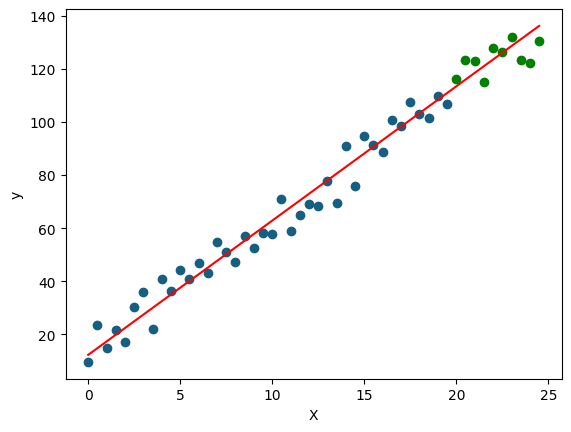

In [560]:
# plot the data
plt.figure(figsize=(12,8))
_, ax = plt.subplots()
ax.scatter(X_train.detach().cpu().numpy(),y_train.detach().cpu().numpy(),color="#155F82")
ax.scatter(X_test.detach().cpu().numpy(),y_test.detach().cpu().numpy(),color="green")
ax.plot(X, ww*X + bb, color = "r")
ax.set_xlabel("X")
ax.set_ylabel("y")
plt.show();